---
date: "2026-05-09"
date-modified: last-modified
format:
  html:
    toc: true
---


# 1. The Hypergeometric Distribution

While the [Binomial distribution](bernoulli-and-binomial-distributions.ipynb#the-binomial-distribution) models the number of successes when sampling *with* replacement, the **Hypergeometric distribution** models the number of successes when we sample *without* replacement.

::: {.callout-tip title="Story: The Hypergeometric Distribution"}
Imagine an urn containing exactly $w$ white balls and $b$ black balls. We draw a sample of $n$ balls entirely at random, without putting any back into the urn, meaning all possible samples are equally likely.

If we define a [random variable](random-variables.ipynb) $X$ to represent the number of white balls successfully drawn in our sample, then $X$ follows a Hypergeometric distribution.
We denote this mathematically as $X \sim \text{HGeom}(w, b, n)$.
:::

## 1.1 The Hypergeometric PMF

**Theorem:** If $X \sim \text{HGeom}(w, b, n)$, its Probability Mass Function (PMF) is given by:

$$P(X = k) = \frac{\binom{w}{k}\binom{b}{n-k}}{\binom{w+b}{n}}$$

for any integer $k$ satisfying $0 \le k \le w$ and $0 \le n-k \le b$. For all other values, $P(X=k) = 0$.

**Proof:**
This formula is derived directly from the naive definition of probability (favorable outcomes divided by total outcomes).

1. **Total Outcomes:** The total number of ways to draw an unordered sample of $n$ balls from a combined pool of $w+b$ balls is the combination of $w+b$ choose $n$.
2. **Favorable Outcomes:** To obtain exactly $k$ white balls, we must select $k$ balls from the $w$ available white balls. Simultaneously, the remaining $n-k$ balls in our sample must be chosen from the $b$ available black balls.
3. By the multiplication rule of counting, the number of favorable combinations is the product of these two choices. Dividing this product by the total possible samples gives the PMF.
*(Note: Vandermonde's Identity guarantees that summing these probabilities over all valid $k$ equals exactly 1)*. $\square$

::: {.callout-note title="Intuition: The Dual 'Tags' Perspective"}
The Hypergeometric story extends beyond literal urns to any population classified by two sets of binary "tags".

* **Tag Set 1 (Inherent):** White vs. Black (e.g., Tagged Elk vs. Untagged Elk, Aces vs. Non-Aces).
* **Tag Set 2 (Experimental):** Sampled vs. Not Sampled (or Recaptured vs. Not Recaptured).

At least one of these tag sets must be assigned completely at random. The variable $X \sim \text{HGeom}(w, b, n)$ strictly counts the items that possess *both* the first tag (e.g., White) and the second tag (e.g., Sampled).
:::

## 1.2 Symmetry of the Hypergeometric

**Theorem:** The distributions $\text{HGeom}(w, b, n)$ and $\text{HGeom}(n, w+b-n, w)$ are mathematically identical.

**Proof:**
We can prove this intuitively by swapping the two sets of tags.
Let $X$ count the number of balls that are both *White* and *Sampled*. Instead of fixing the colors and randomly picking which $n$ balls get sampled, we could equivalently fix which $n$ balls are sitting in our sample tray, and randomly assign "white" paint to $w$ of the total balls.
In this swapped perspective, the "urn" has $n$ sampled items and $w+b-n$ unsampled items, and we draw $w$ items to paint white. Because both scenarios simply count the intersection of the two tags, their distributions are identical. $\square$

## 1.3 Static Visualization

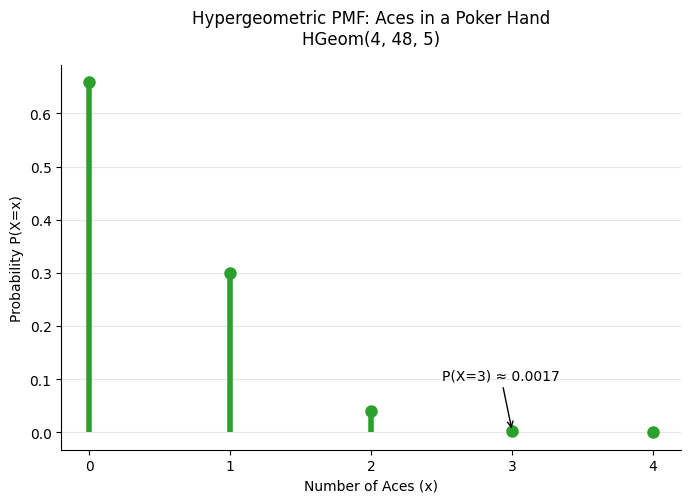

In [2]:
#| label: fig-hypergeometric-pmf
#| fig-cap: "The Hypergeometric PMF for drawing 5 cards from a 52-card deck and counting the Aces."

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import hypergeom

# Example: Aces in a 5-card poker hand (w=4 aces, b=48 non-aces, n=5 draws)
w, b, n = 4, 48, 5
x = np.arange(0, 5) # Possible number of aces (0 to 4)
pmf = hypergeom.pmf(x, w+b, w, n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.vlines(x, 0, pmf, color='#2ca02c', lw=4)
ax.plot(x, pmf, 'o', color='#2ca02c', markersize=8)

ax.set_title(f"Hypergeometric PMF: Aces in a Poker Hand\nHGeom({w}, {b}, {n})", pad=15)
ax.set_xlabel("Number of Aces (x)")
ax.set_ylabel("Probability P(X=x)")
ax.set_xticks(x)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate the specific probability of getting exactly 3 aces (~0.0017)
ax.annotate(f'P(X=3) ≈ {pmf[3]:.4f}', xy=(3, pmf[3]), xytext=(2.5, 0.1),
            arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.show()